# Clonal Selection Algorithm in Python
**Author:** @VedantAndhale

In [20]:
import random
import matplotlib.pyplot as plt

## Step 1: Generate Initial Population
The initial population consists of binary strings, where each string represents a potential solution. The length of the string corresponds to the problem's genome length.

In [13]:
def generate_population(pop_size, genome_length):
    """Create initial population of random binary strings."""
    return [
        [random.randint(0, 1) for _ in range(genome_length)] for _ in range(pop_size)
    ]

## Step 2: Evaluate Affinity
Affinity measures the fitness of each individual in the population. In this example, the fitness is the count of ones in the binary string.

In [14]:
def affinity(individual):
    """Affinity is the fitness: count of ones in the binary string."""
    return sum(individual)

## Step 3: Selection
Select the top individuals based on their fitness to form the next generation.

In [15]:
def select(population, affinities, num_selected):
    """Select the top num_selected individuals by fitness."""
    paired = list(zip(population, affinities))
    paired.sort(key=lambda x: x[1], reverse=True)
    return [ind for ind, _ in paired[:num_selected]]

## Step 4: Clone and Hypermutate
Each selected individual is cloned, and the clones undergo hypermutation. The mutation rate is inversely proportional to the individual's fitness.

In [16]:
def clone_and_hypermutate(selected, aff_selected, beta, rho):
    """Clone each selected individual and apply hypermutation."""
    clones = []
    for individual, aff in zip(selected, aff_selected):
        num_clones = max(1, int(beta * aff))
        for _ in range(num_clones):
            # clone
            clone = individual.copy()
            # mutation rate inversely proportional to affinity
            mutation_rate = rho / (aff + 1)
            # hypermutation: flip bits
            clone = [
                1 - gene if random.random() < mutation_rate else gene for gene in clone
            ]
            clones.append(clone)
    return clones

## Step 5: Clonal Selection Process
Combine the original population with the clones, evaluate their fitness, and select the best individuals to form the next generation.

In [17]:
def clonal_selection(pop_size, genome_length, generations, beta=0.1, rho=0.5):
    """Run the clonal selection algorithm."""
    population = generate_population(pop_size, genome_length)
    best_history = []

    for gen in range(generations):
        # evaluate
        aff = [affinity(ind) for ind in population]
        best_history.append(max(aff))
        # select
        num_selected = pop_size // 2
        selected = select(population, aff, num_selected)
        aff_selected = [affinity(ind) for ind in selected]
        # clone & hypermutate
        clones = clone_and_hypermutate(selected, aff_selected, beta, rho)
        # combine and select next generation
        combined = population + clones
        combined_aff = [affinity(ind) for ind in combined]
        population = select(combined, combined_aff, pop_size)

    return population, best_history

## Step 6: Run the Algorithm
Define the parameters and run the clonal selection algorithm. Observe the best fitness over generations.

In [ ]:
POP_SIZE = 20
GENOME_LENGTH = 30
GENERATIONS = 50
BETA = 0.5  # cloning factor
RHO = 0.3  # mutation scaling factor

final_pop, history = clonal_selection(POP_SIZE, GENOME_LENGTH, GENERATIONS, BETA, RHO)
print(f"Best fitness over generations: {history[-1]}")

Best fitness over generations: 30


## Step 7: Visualize Results
Plot the best fitness over generations to visualize the algorithm's performance.

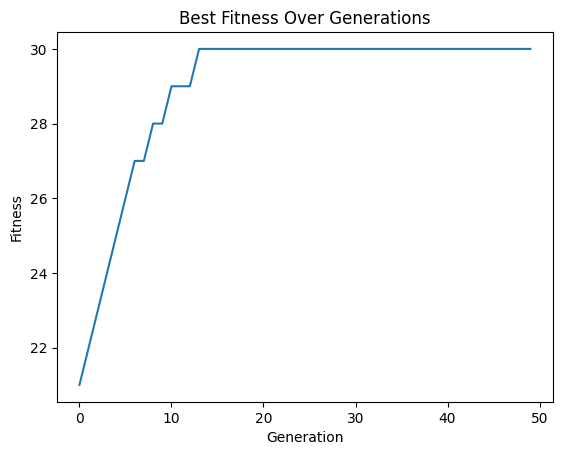

In [19]:
# Visualization of the best fitness over generations
plt.plot(history)
plt.title("Best Fitness Over Generations")
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.show()